# MARL Tabular Q Analysis

Use this notebook to inspect results produced by `experiments/n_player_experiments_simple.py`.
It intentionally mirrors the structure of the DQN notebook while staying independent
so we can iterate on the tabular agent without touching legacy analyses.

## How to use
- Run the simple experiment script to generate results in `analysis/results`.
- Select the JSON artifact you want to inspect below.
- The helper code will load the per-episode Parquet/CSV it references and compute a few summaries.

If you add new fields to the simple simulation, extend the summaries here; the notebook is meant
to be a lightweight playground for the tabular agent.

In [ ]:
from pathlib import Path
import sys

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'analysis' else NOTEBOOK_DIR
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from analysis import analysis_utils

DATA_DIR = NOTEBOOK_DIR / 'results'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR = NOTEBOOK_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# target_res = "n_player_carryover_simplerule_tab_q_learning_N5_lambda1_rho1-0.9-0.5-0.1-0_20251125T015414Z"
target_res = "n_player_carryover_simplerule_reset_tab_q_learning_3_state_N5_lambda1_rho1-0.9-0.5-0.1-0_20251202T233010Z"
TARGET_FIG_DIR = FIG_DIR / target_res
TARGET_FIG_DIR.mkdir(exist_ok=True)


In [3]:
# Load experiment results
target_file = DATA_DIR / f'{target_res}.json'

if not target_file.exists():
    print(f"Experiment file {target_file.name} not found. Run the experiment or update the path above.")
else:
    print(f'Loaded experiment: {target_file.name}')
    experiment = analysis_utils.load_experiment(target_file)
    frame = analysis_utils.runs_to_frame(experiment)
    display(frame.head())

Loaded experiment: n_player_carryover_simplerule_tab_q_learning_3_state_N5_lambda1_rho1-0.9-0.5-0.1-0_20251202T230750Z.json


,scenario,share_parameters,seed,episode,mean_profit,avg_price,avg_lowest_price,repricer_share,network_density,weighted_density,...,action_share_undercut_reset,action_share_undercut_reset_raise,action_share_match,action_share_match_raise,action_share_match_reset,action_share_match_reset_raise,action_share_above,action_share_above_raise,action_share_above_reset,action_share_above_reset_raise
0,rho_0,False,0,0.0,0.010,2.272,2.10,1.0,0.40,0.204082,...,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0,0.0,0.0
1,rho_0,False,0,1.0,0.000,2.400,2.00,0.8,0.15,0.150000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0
2,rho_0,False,0,2.0,0.000,3.004,2.00,0.8,0.30,0.153061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,0.0
3,rho_0,False,0,3.0,0.094,4.412,2.50,0.6,0.10,0.100000,...,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0,0.0,0.0
4,rho_0,False,0,4.0,0.000,3.220,2.01,0.8,0.15,0.150000,...,0.0,0.0,0.4,0.0,0.0,0.0,0.2,0.0,0.0,0.0


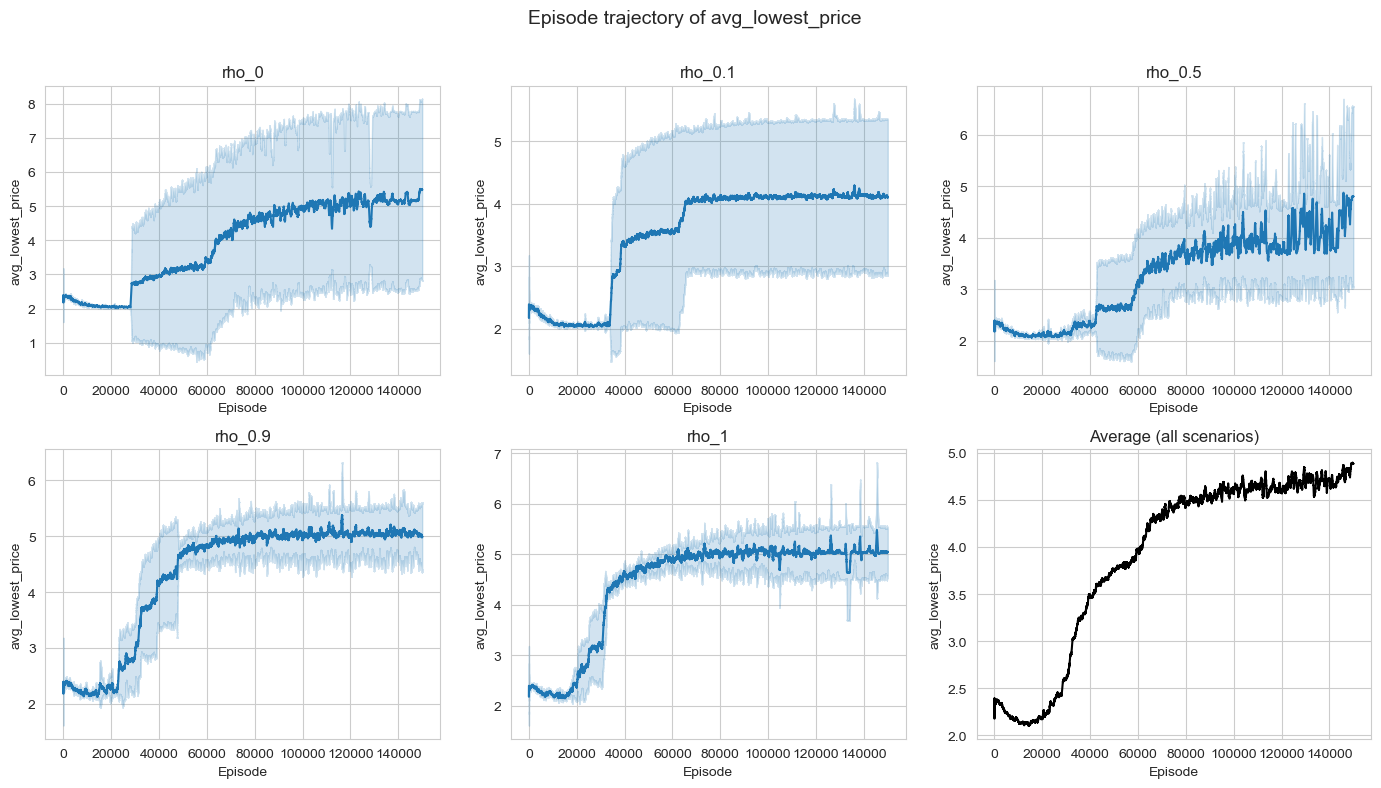

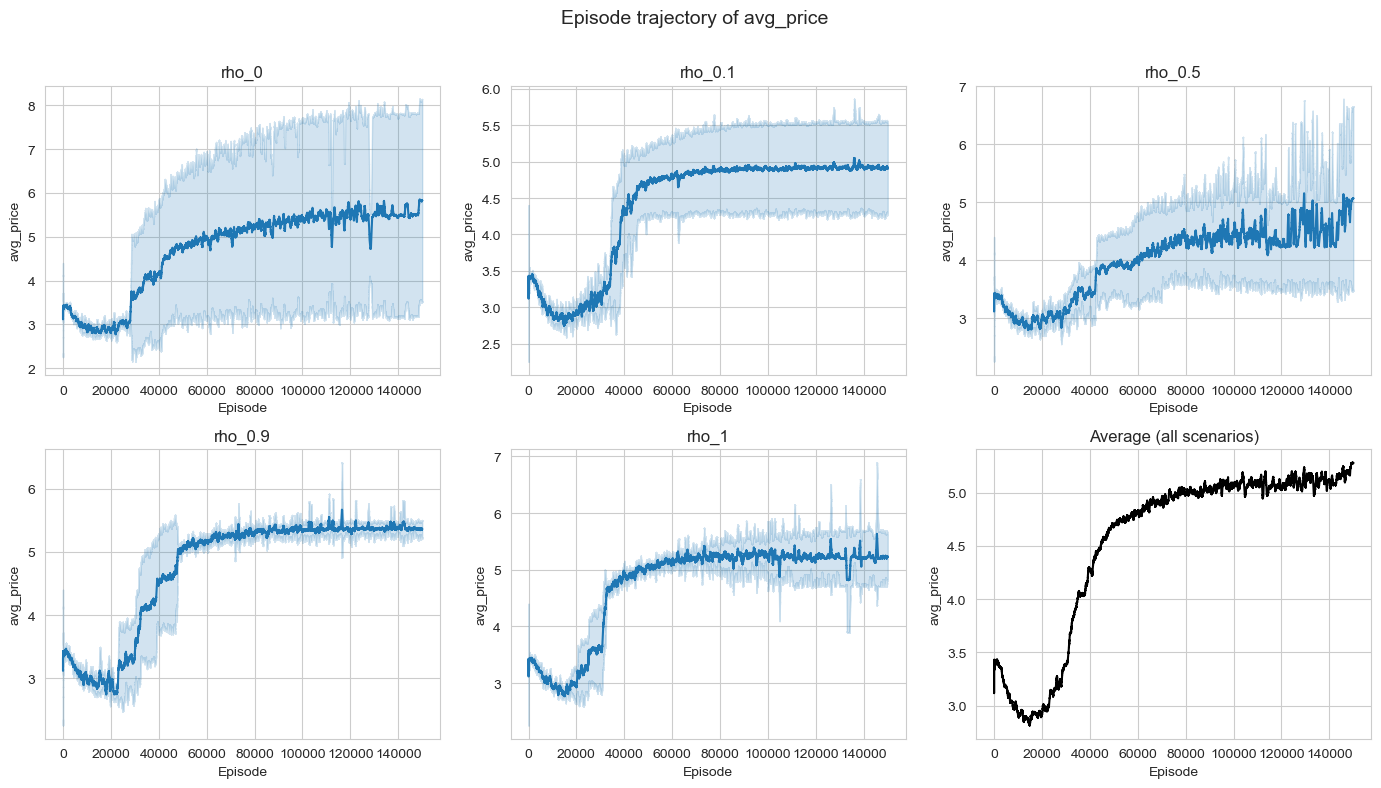

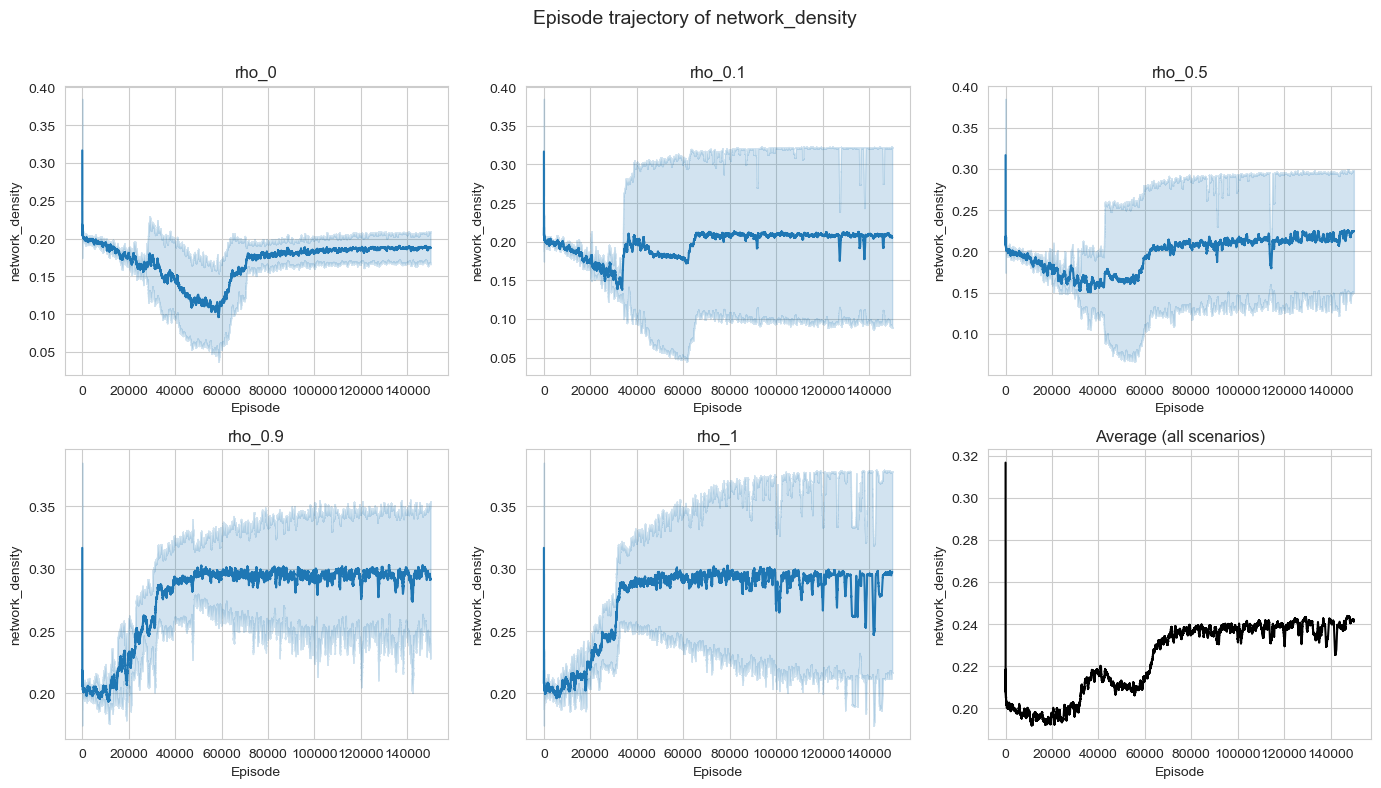

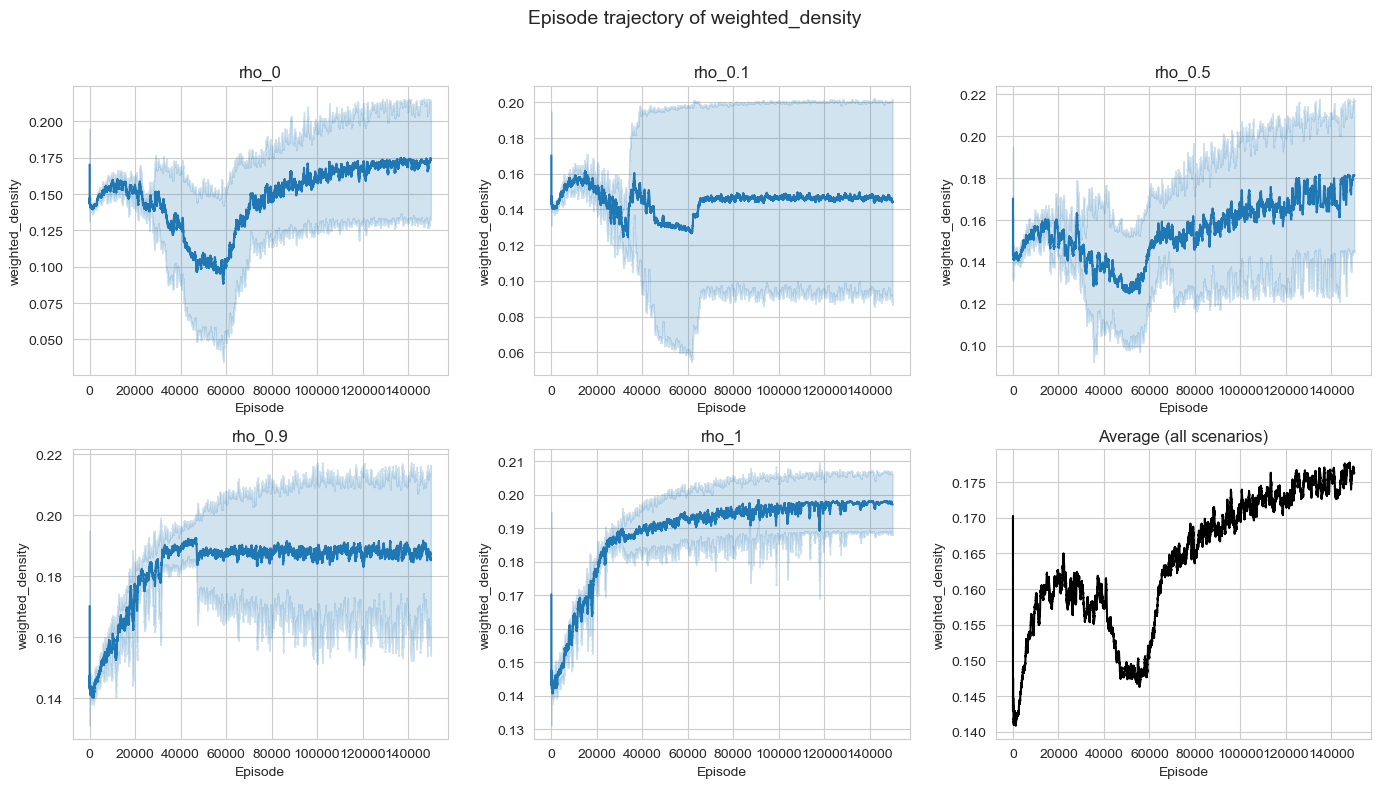

In [4]:
# Plot metrics over episodes
metrics = [
    'avg_lowest_price',
    'avg_price',
    # 'mean_profit',
    # 'repricer_share',
    'network_density',
    'weighted_density',
]
for metric in metrics:
    analysis_utils.plot_metric_over_episodes(
        frame,
        metric,
        smoothing=500,
        use_log_x=False,
        title=f'Episode trajectory of {metric}',
        save_path=TARGET_FIG_DIR / f'{metric}_episodes.png',
    )

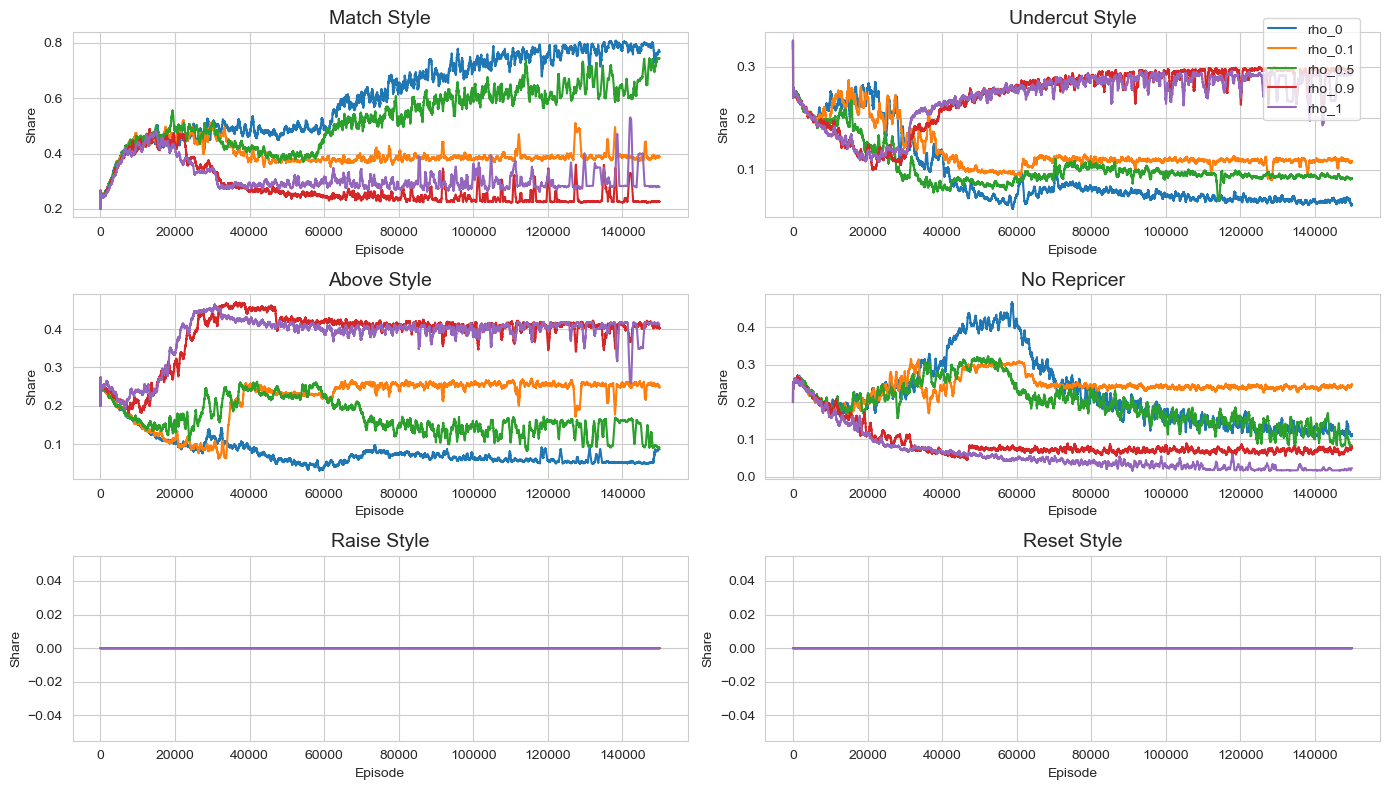

In [5]:
# Plot action family shares over episodes
analysis_utils.plot_action_family_shares(
    frame,
    use_log_x=False,
    smoothing=500,
    families=["Match Style", "Undercut Style", "Above Style", "No Repricer" , 'Raise Style', 'Reset Style'],
    layout=(3, 2),
    save_path=TARGET_FIG_DIR / 'action_family_over_episodes.png',
)